#**seq2seq Model**
The Sequence-to-Sequence (Seq2Seq) model is a neural network architecture commonly employed in machine learning to transform one sequence of data into another. It takes an input sequence and produces a corresponding output sequence. Seq2Seq models have played a crucial role in various domains, including natural language processing (NLP), machine translation, speech recognition, and time-series forecasting.
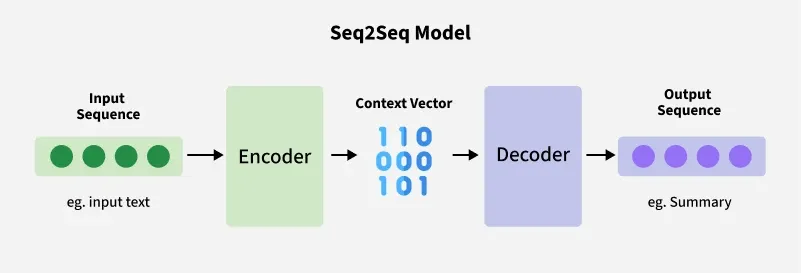

###Both the input and the output are treated as sequences of varying lengths and the model is composed of two parts:
1. **Encoder:**
  * Processes the input sequence token by token.
  * Encodes the entire sequence into a fixed-length context vector (or a series of hidden states) that summarizes the important information from the input.
  * After processing the entire sequence, the encoder produces a context vector i.e a fixed-length representation summarizing the important information from the input.
2. **Decoder:**
  * Takes the context vector as input.
  * The decoder takes the context vector and generates the output sequence one token at a time.  
  

The model is commonly used in tasks where there is a need to map sequences of varying lengths such as converting a sentence in one language to another or predicting a sequence of future events based on past data i.e time-series forecasting.

##**GRU (Gated Recurrent Unit):**
A GRU (Gated Recurrent Unit) is a type of recurrent neural network (RNN) architecture designed to efficiently capture dependencies in sequential data — such as text, speech, or time series — while addressing some of the limitations of traditional RNNs, like the vanishing gradient problem.

It was introduced as a simpler alternative to the Long Short-Term Memory (LSTM) network.

**A GRU has two main gates:**
1. **Update Gate (zₜ):** Determines how much of the previous information needs to be carried forward to the next step.
2. **Reset Gate (rₜ):** Controls how much of the past information to forget.

Unlike LSTMs, GRUs do not have a separate cell state — they merge it with the hidden state, which makes them computationally simpler and faster to train.



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

###**Encoder:**
 * Each input token is converted to a dense vector (embedding).
 * GRU processes the sequence one token at a time, updating its hidden state.
 * The final hidden state is returned as the context vector, summarizing the input sequence.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return hidden

###**Decoder:**
* Takes the current input token and converts it to an embedding.
* GRU uses the previous hidden state (or context vector initially) to compute the new hidden state.
* The output is passed through a linear layer to get predicted token probabilities.

In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input, hidden):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output.squeeze(0))
        return prediction, hidden

##**Seq2Seq Model with Teacher Forcing:**
* **Batch size & vocab size:** extracted from input and decoder.
* **Encoding:** input sequence → encoder → context vector (hidden).
* **Start token:** initialize decoder with token 0.
* **Loop over max_len:**
  * Decoder predicts next token.
  * top1 → token with max probability.
  * Append top1 to outputs.
* **Teacher forcing:** sometimes feed true target token instead of prediction.
* **Return predictions:** concatenated sequence of token IDs.




##**Teacher Forcing:**
Teacher Forcing is a training method where the true previous output is fed into the decoder instead of the model's own prediction, helping the model learn faster but possibly causing reliance on ground-truth data.

In a Seq2Seq model, the decoder generates the output sequence one step at a time.

At each step, it predicts the next token (word, number, etc.) based on:
* the previous hidden state, and
* the previous output.

But during training, the model’s previous output may not always be correct — if it makes an early mistake, that error can propagate through the whole sequence.

Teacher forcing solves this by providing the correct (ground-truth) output from the training data as the next input to the decoder — instead of the model’s own prediction.

* **Benefits:**
  * **Faster convergence:** The model learns the correct sequence structure quickly.
  * **Prevents error accumulation:** Mistakes don’t snowball through the sequence.
* **Drawbacks:**
  * During inference (testing), the true target isn’t available — the model must rely on its own previous predictions.
  * If it was trained heavily with teacher forcing, it might perform poorly when it has to use its own outputs at test time (this is called exposure bias).

In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=10, teacher_forcing_ratio=0.5):
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc.out_features
        outputs = []

        hidden = self.encoder(src)

        input = torch.zeros(batch_size, dtype=torch.long).to(self.device)

        for t in range(max_len):
            output, hidden = self.decoder(input, hidden)
            top1 = output.argmax(1)
            outputs.append(top1.unsqueeze(0))

            if trg is not None and t < trg.shape[0] and torch.rand(1).item() < teacher_forcing_ratio:
                input = trg[t]
            else:
                input = top1

        outputs = torch.cat(outputs, dim=0)
        return outputs

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VOCAB_SIZE = 10
EMB_DIM = 8
HID_DIM = 16
SEQ_LEN = 5
BATCH_SIZE = 2

enc = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
dec = Decoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
model = Seq2Seq(enc, dec, device).to(device)

src = torch.randint(1, VOCAB_SIZE, (SEQ_LEN, BATCH_SIZE)).to(device)
trg = torch.randint(1, VOCAB_SIZE, (SEQ_LEN, BATCH_SIZE)).to(device)

outputs = model(src, trg, max_len=SEQ_LEN, teacher_forcing_ratio=0.7)

print("Source sequence (input tokens):")
print(src.T)
print("\nTarget sequence (true tokens):")
print(trg.T)
print("\nPredicted sequence (model output tokens):")
print(outputs.T)

Source sequence (input tokens):
tensor([[4, 8, 8, 9, 6],
        [9, 7, 7, 9, 8]])

Target sequence (true tokens):
tensor([[2, 5, 9, 5, 7],
        [2, 5, 2, 4, 7]])

Predicted sequence (model output tokens):
tensor([[5, 5, 5, 5, 5],
        [5, 5, 3, 3, 5]])


#Using Keras

In [ ]:
# Simple Seq2Seq example using GRU in Keras
import numpy as np
from keras.models import Model
from keras.layers import Input, GRU, Dense
from keras.utils import to_categorical

In [ ]:
input_texts = ["hello", "hi", "cat", "dog"]
target_texts = ["olleh", "ih", "tac", "god"]

# Character vocabulary
chars = sorted(list(set("".join(input_texts + target_texts))))
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}
num_chars = len(chars)

max_len = max(len(txt) for txt in input_texts)

# Encode input/output sequences as vectors
def encode(texts):
    X = np.zeros((len(texts), max_len, num_chars))
    for i, text in enumerate(texts):
        for t, char in enumerate(text):
            X[i, t, char2idx[char]] = 1
    return X

encoder_input = encode(input_texts)
decoder_output = encode(target_texts)

In [ ]:
#  Model Architecture (Seq2Seq)

latent_dim = 64  # hidden units

# Encoder
encoder_inputs = Input(shape=(None, num_chars))
encoder_gru = GRU(latent_dim, return_state=True)
encoder_outputs, encoder_state = encoder_gru(encoder_inputs)

# Decoder
decoder_inputs = Input(shape=(None, num_chars))
decoder_gru = GRU(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _ = decoder_gru(decoder_inputs, initial_state=encoder_state)
decoder_dense = Dense(num_chars, activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, None, 10)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None, None, 10)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_8 (GRU)         │ [(None, 64),      │     14,592 │ input_layer_9[0]… │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_9 (GRU)         │ [(None, None,     │     14,592 │ input_layer_10[0… │
│                     │ 64), (None, 64)]  │            │ gru_8[0][1]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, None, 10)  │        650 │ gru_9[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 89,504 (349.63 KB)

 Trainable params: 29,834 (116.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,670 (233.09 KB)

In [ ]:
# Training

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.fit([encoder_input, encoder_input], decoder_output, epochs=300, verbose=0)

In [ ]:
encoder_model = Model(encoder_inputs, encoder_state)

# Decoder model
decoder_state_input = Input(shape=(latent_dim,))
decoder_outputs_inf, decoder_state_inf = decoder_gru(
    decoder_inputs, initial_state=decoder_state_input
)
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)
decoder_model = Model(
    [decoder_inputs, decoder_state_input],
    [decoder_outputs_inf, decoder_state_inf],
)

In [ ]:
# Testing

for seq_index in range(len(input_texts)):
    input_seq = encoder_input[seq_index: seq_index + 1]
    state = encoder_model.predict(input_seq, verbose=0)

    # Start decoding using the same input (toy setup)
    target_seq = input_seq.copy()
    output_tokens, _ = decoder_model.predict([target_seq, state], verbose=0)

    print(f"Input: {input_texts[seq_index]} → Predicted Output Shape: {output_tokens.shape}")

Input: hello → Predicted Output Shape: (1, 5, 10)
Input: hi → Predicted Output Shape: (1, 5, 10)
Input: cat → Predicted Output Shape: (1, 5, 10)
Input: dog → Predicted Output Shape: (1, 5, 10)


#Attention Mechanism:
In a standard Sequence-to-Sequence (Seq2Seq) model (using LSTM or GRU):
* The encoder reads an input sequence (e.g., a sentence in English).
* It compresses all that information into a single fixed-length vector (called the context vector).
* The decoder then uses that one vector to generate the output sequence (e.g., in French).

**Problem:** If the input sequence is long, that one fixed-size vector can’t hold all the important details.
The decoder may “forget” earlier parts of the input — especially for long sentences.

Instead of using one single context vector, the attention mechanism lets the decoder:
  
  **“Look back at”** (or attend to) different parts of the input sequence at each step of decoding.
  
  When translating the **targeted word** of the output, the decoder gives more attention to the part of the input that is most relevant to that word.

  **In simple words**, The attention mechanism computes attention weights that tell us how important each encoder hidden state is for producing the current output word.
.

##**Types of Attention:**
1. **Bahdanau Attention (Additive):** introduced in 2015
    * Computes attention weights using a small feed-forward neural network.
    * Adds encoder and decoder states before applying tanh and softmax.
2. **Luong Attention (Multiplicative / Dot-Product):** introduced in 2015
    * Computes similarity using a dot product between encoder and decoder states.
    * Faster and more memory-efficient.
3. **Self-Attention:** used in Transformers (e.g., BERT, GPT, etc.)
    * Each token attends to other tokens in the same sequence.
    * This is what made models like GPT possible.
    

In [ ]:
import numpy as np
import tensorflow as tf
from keras.models import Model
from keras.layers import Input, GRU, Dense, Dot, Activation, Concatenate

In [ ]:
# Data Preparation

input_texts = ["hello", "hi", "cat", "dog"]
target_texts = ["ہیلو", "کیسے ہیں", "بلی", "کتا"]

chars = sorted(list(set("".join(input_texts + target_texts))))
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}
num_chars = len(chars)
max_len = max(len(txt) for txt in input_texts)

In [ ]:
def encode(texts):
    X = np.zeros((len(texts), max_len, num_chars))
    for i, text in enumerate(texts):
        for t, char in enumerate(text):
            X[i, t, char2idx[char]] = 1
    return X

encoder_input = encode(input_texts)
decoder_output = encode(target_texts)




IndexError: index 5 is out of bounds for axis 1 with size 5

In [ ]:
# Seq2Seq + Luong Attention Model

latent_dim = 64

# --- Encoder ---
encoder_inputs = Input(shape=(None, num_chars))
encoder_outputs, encoder_state = GRU(latent_dim, return_sequences=True, return_state=True)(encoder_inputs)

# --- Decoder ---
decoder_inputs = Input(shape=(None, num_chars))
decoder_gru = GRU(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _ = decoder_gru(decoder_inputs, initial_state=encoder_state)

# --- Luong Attention ---
# Compute alignment scores (dot product between decoder outputs & encoder outputs)
attention = Dot(axes=[2, 2])([decoder_outputs, encoder_outputs])  # shape: (batch, dec_steps, enc_steps)
attention = Activation('softmax', name='attention_weights')(attention)

# Compute context vector (weighted sum of encoder outputs)
context = Dot(axes=[2, 1])([attention, encoder_outputs])  # (batch, dec_steps, latent_dim)

# Combine context with decoder outputs
decoder_combined_context = Concatenate(axis=-1)([context, decoder_outputs])

# Final output layer
output_dense = Dense(num_chars, activation='softmax')
decoder_pred = output_dense(decoder_combined_context)

In [ ]:
# --- Full model ---
model = Model([encoder_inputs, decoder_inputs], decoder_pred)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, None, 10)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, None, 10)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_6 (GRU)         │ [(None, None,     │     14,592 │ input_layer_7[0]… │
│                     │ 64), (None, 64)]  │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_7 (GRU)         │ [(None, None,     │     14,592 │ input_layer_8[0]… │
│                     │ 64), (None, 64)]  │            │ gru_6[0][1]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, None,      │          0 │ gru_7[0][0],      │
│                     │ None)             │            │ gru_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, None,      │          0 │ dot[0][0]         │
│ (Activation)        │ None)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, None, 64)  │          0 │ attention_weight… │
│                     │                   │            │ gru_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None, 128) │          0 │ dot_1[0][0],      │
│ (Concatenate)       │                   │            │ gru_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, None, 10)  │      1,290 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 30,474 (119.04 KB)

 Trainable params: 30,474 (119.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Train Model
model.fit([encoder_input, encoder_input], decoder_output, epochs=300, verbose=0)


# Visualize Attention Weights

# Let's extract attention weights for a sample
attention_layer = model.get_layer('attention_weights')

# Define a sub-model to output attention given input
attention_model = Model(inputs=[encoder_inputs, decoder_inputs], outputs=attention_layer.output)

sample_idx = 0
attn_weights = attention_model.predict([encoder_input[[sample_idx]], encoder_input[[sample_idx]]])
print(f"Input: {input_texts[sample_idx]}")
print("Attention weights shape:", attn_weights.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
Input: hello
Attention weights shape: (1, 5, 5)


**(1, 5, 5) means:**

* Batch size = 1
* Decoder length = 5 (output chars)
* Encoder length = 5 (input chars)

Each element [i, j] in that matrix tells how much attention the decoder’s i-th output gives to the j-th input position.

| Step                | Concept           | Explanation                                                                           |
| ------------------- | ----------------- | ------------------------------------------------------------------------------------- |
| **Encoder**         | Reads input       | Produces hidden states for every input token                                          |
| **Decoder**         | Generates output  | Uses previous output + context vector                                                 |
| **Luong Attention** | Focus mechanism   | Computes how much each input position should influence the current output             |
| **Dot Product**     | Attention score   | Measures similarity between decoder and encoder states                                |
| **Softmax**         | Attention weights | Converts scores to probabilities that sum to 1                                        |
| **Context Vector**  | Weighted sum      | Summarizes the relevant information from the input sequence                           |
| **Concatenate**     | Combine           | The decoder uses both its own output and the context vector to predict the next token |
